#SOM Clustering  for Multi-Building Energy Benchmarking

In [ ]:
pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=66fadbd651b76bba07018aac524a7f16f694224d56152177724b3e7cd69c4125
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


## 1- Data loading

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score

# LOAD DATASETS


pca_data = pd.read_csv("pca_data.csv")
clean_data = pd.read_csv("clean_data.csv")

print("Original PCA datapoints:", len(pca_data))
print("Original clean datapoints:", len(clean_data))


Original PCA datapoints: 135735
Original clean datapoints: 135735


## 2- SOM clustering method

In [ ]:
sample_size = 50000

sample_index = pca_data.sample(
    n=min(sample_size, len(pca_data)),
    random_state=42
).index

pca_sample = pca_data.loc[sample_index].copy().reset_index(drop=True)
clean_sample = clean_data.loc[sample_index].copy().reset_index(drop=True)

print("Sampled datapoints:", len(pca_sample))



X = pca_sample.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



# TRAIN SOM
# Internal SOM grid = 8 x 8 = 64 nodes
# Final clusters = 8


som_grid_x = 8
som_grid_y = 8
final_clusters = 8

som = MiniSom(
    x=som_grid_x,
    y=som_grid_y,
    input_len=X_scaled.shape[1],
    sigma=2.2,
    learning_rate=0.6,
    neighborhood_function="gaussian",
    random_seed=42
)

som.random_weights_init(X_scaled)

som.train_random(
    data=X_scaled,
    num_iteration=10000
)



# GET SOM WINNING NODES


winning_nodes = np.array([som.winner(row) for row in X_scaled])

winning_node_ids = np.array([
    node[0] * som_grid_y + node[1]
    for node in winning_nodes
])


node_weights = som.get_weights().reshape(
    som_grid_x * som_grid_y,
    X_scaled.shape[1]
)

node_kmeans = KMeans(
    n_clusters=final_clusters,
    random_state=42,
    n_init=20
)

node_cluster_labels = node_kmeans.fit_predict(node_weights)

labels = np.array([
    node_cluster_labels[node_id]
    for node_id in winning_node_ids
])

pca_sample["cluster"] = labels
clean_sample["cluster"] = labels


##3- Results and performance

In [ ]:

print("\n===== SOM CLUSTER INFO =====")
print("Clusters:", len(np.unique(labels)))
print(clean_sample["cluster"].value_counts().sort_index())

print("\nUnique final labels:", np.unique(labels))



# 1. CLUSTERING PERFORMANCE


clustering_performance = pd.DataFrame([{
    "Method": "SOM",
    "Clusters": len(np.unique(labels)),
    "Silhouette": silhouette_score(X_scaled, labels),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
    "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels)
}])

print("\n===== CLUSTERING PERFORMANCE =====")
print(clustering_performance)

# 2. BENCHMARKING QUALITY


benchmark_cols = ["site_eui", "ghg_emissions_int"]

missing_cols = [
    col for col in benchmark_cols
    if col not in clean_sample.columns
]

if missing_cols:
    raise ValueError(f"Missing benchmarking columns: {missing_cols}")

cluster_mean = clean_sample.groupby("cluster")[benchmark_cols].mean()
cluster_std = clean_sample.groupby("cluster")[benchmark_cols].std()

cv = cluster_std / cluster_mean

avg_cv_site = cv["site_eui"].mean()
avg_cv_ghg = cv["ghg_emissions_int"].mean()

cv["avg_cv"] = (
    cv["site_eui"] + cv["ghg_emissions_int"]
) / 2

best_avg_cluster_cv = cv["avg_cv"].min()
best_single_cv = cv[["site_eui", "ghg_emissions_int"]].min().min()

benchmark_quality = pd.DataFrame([{
    "Method": "SOM",
    "Avg CV (site_eui)": avg_cv_site,
    "Avg CV (ghg_emissions)": avg_cv_ghg,
    "Best Avg Cluster CV": best_avg_cluster_cv,
    "Best Single CV": best_single_cv
}])

print("\n===== BENCHMARKING QUALITY =====")
print(benchmark_quality)


NT
# Baseline calculated from SAME sampled clean data


global_site = clean_sample["site_eui"].std()
global_ghg = clean_sample["ghg_emissions_int"].std()

cluster_sizes = clean_sample.groupby("cluster").size()

cluster_site_std = (
    cluster_std["site_eui"] * cluster_sizes
).sum() / cluster_sizes.sum()

cluster_ghg_std = (
    cluster_std["ghg_emissions_int"] * cluster_sizes
).sum() / cluster_sizes.sum()

improvement_site = (
    (global_site - cluster_site_std) / global_site
) * 100

improvement_ghg = (
    (global_ghg - cluster_ghg_std) / global_ghg
) * 100

benchmark_improvement = pd.DataFrame([{
    "Method": "SOM",
    "Global Std (site_eui)": global_site,
    "Cluster Avg Std (site_eui)": cluster_site_std,
    "Improvement site_eui (%)": improvement_site,
    "Global Std (ghg_emissions)": global_ghg,
    "Cluster Avg Std (ghg_emissions)": cluster_ghg_std,
    "Improvement ghg_emissions (%)": improvement_ghg
}])

print("\n===== BENCHMARKING IMPROVEMENT =====")
print(benchmark_improvement)


# 4. CLUSTER SUMMARY TABLE

cluster_summary = clean_sample.groupby("cluster")[benchmark_cols].agg(
    ["count", "mean", "std"]
)

print("\n===== CLUSTER SUMMARY =====")
print(cluster_summary)



pca_sample.to_csv("som_clustered_pca_data.csv", index=False)
clean_sample.to_csv("som_clustered_clean_data.csv", index=False)

clustering_performance.to_csv("som_clustering_performance.csv", index=False)
benchmark_quality.to_csv("som_benchmark_quality.csv", index=False)
benchmark_improvement.to_csv("som_benchmark_improvement.csv", index=False)
cluster_summary.to_csv("som_cluster_summary.csv")

print("\nFiles saved successfully.")

Original PCA datapoints: 135735
Original clean datapoints: 135735
Sampled datapoints: 50000

===== SOM CLUSTER INFO =====
Clusters: 8
cluster
0     5341
1     4553
2     8128
3     6216
4     1599
5    16055
6     6744
7     1364
Name: count, dtype: int64

Unique final labels: [0 1 2 3 4 5 6 7]

===== CLUSTERING PERFORMANCE =====
  Method  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
0    SOM         8    0.199643        1.452408        5604.971989

===== BENCHMARKING QUALITY =====
  Method  Avg CV (site_eui)  Avg CV (ghg_emissions)  Best Avg Cluster CV  \
0    SOM           0.450903                0.503454             0.337771   

   Best Single CV  
0        0.304648  

===== BENCHMARKING IMPROVEMENT =====
  Method  Global Std (site_eui)  Cluster Avg Std (site_eui)  \
0    SOM              51.278087                   36.980508   

   Improvement site_eui (%)  Global Std (ghg_emissions)  \
0                 27.882435                    3.858541   

   Cluster Avg Std (ghg_e

## 4- visualization

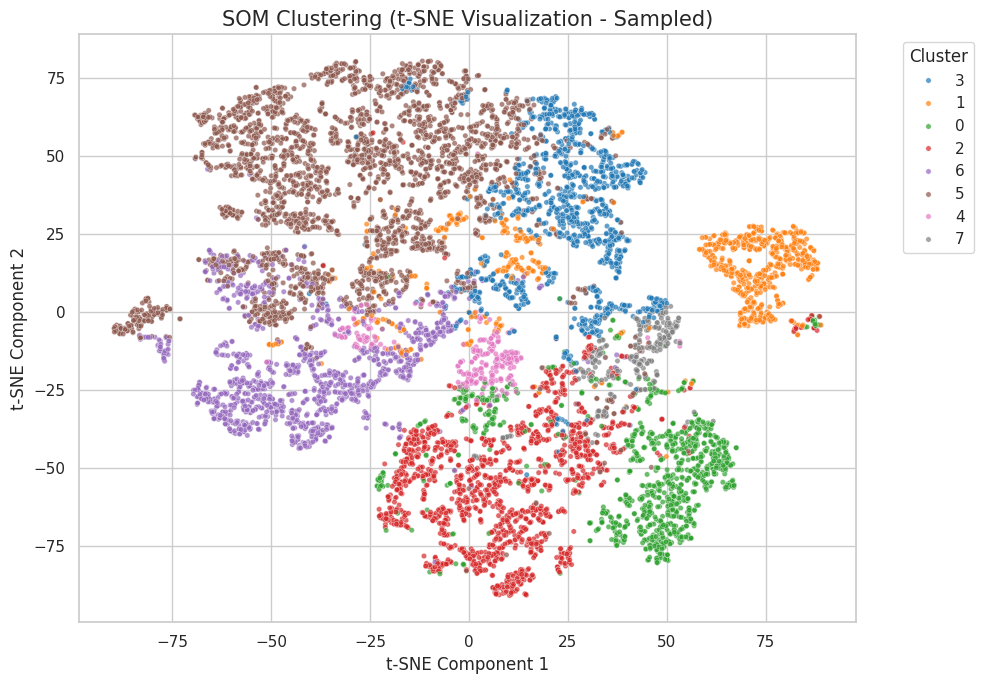

In [ ]:

# SOM t-SNE Visualization


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")



plot_sample_size = 10000
np.random.seed(42)

plot_index = np.random.choice(
    X.shape[0],
    size=min(plot_sample_size, X.shape[0]),
    replace=False
)

X_plot = X.iloc[plot_index].copy() if hasattr(X, "iloc") else X[plot_index]
labels_plot = np.array(labels)[plot_index]



tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_plot)


plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_plot.astype(str),
    palette="tab10",
    s=15,
    alpha=0.7
)

plt.title("SOM Clustering (t-SNE Visualization - Sampled)", fontsize=15)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("som_tsne_visualization_sampled.png", dpi=300)
plt.show()